In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
import glob
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
!pip install tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/Densenet_single_model_dataset/Parkinson_dataset.zip"

UNZIP_DIR = "/content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here"

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here"

MODEL_DIR = os.path.join(SAVE_DIR, "models")
HISTORY_DIR = os.path.join(SAVE_DIR, "history_files")
GRAPH_DIR = os.path.join(SAVE_DIR, "graphs")
CM_DIR = os.path.join(SAVE_DIR, "confusion_matrices")
REPORT_DIR = os.path.join(SAVE_DIR, "reports")

for d in [UNZIP_DIR, SAVE_DIR, MODEL_DIR, HISTORY_DIR, GRAPH_DIR, CM_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

print("ZIP_PATH:", ZIP_PATH)
print("UNZIP_DIR:", UNZIP_DIR)
print("SAVE_DIR:", SAVE_DIR)

ZIP_PATH: /content/drive/MyDrive/Colab Notebooks/Densenet_single_model_dataset/Parkinson_dataset.zip
UNZIP_DIR: /content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here
SAVE_DIR: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here


In [4]:
import zipfile
import os # Ensure os is imported here as well, though it's in a previous cell

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

# Always attempt to unzip to ensure the new UNZIP_DIR is populated correctly
# This bypasses the check if the directory is already populated, forcing a fresh extract
# or adding to existing content, which is necessary to fix 'No images found' if previous unzipping was wrong.
print("Unzipping dataset to:", UNZIP_DIR)
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(UNZIP_DIR)
print("Dataset unzipped to:", UNZIP_DIR)

Unzipping dataset to: /content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here
Dataset unzipped to: /content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here


In [5]:
print(f"Contents of UNZIP_DIR: {UNZIP_DIR}")

# List immediate contents of the UNZIP_DIR
if os.path.exists(UNZIP_DIR):
    print("Immediate contents:")
    for item in os.listdir(UNZIP_DIR):
        print(f"- {item}")

    # Optionally, list contents of the first level subdirectories to get a better sense of structure
    for item in os.listdir(UNZIP_DIR):
        item_path = os.path.join(UNZIP_DIR, item)
        if os.path.isdir(item_path):
            print(f"  Contents of sub-directory '{item}':")
            for sub_item in os.listdir(item_path):
                print(f"  - {sub_item}")
                # Limit to first few items to avoid excessive output
                if len(os.listdir(item_path)) > 5 and os.listdir(item_path).index(sub_item) >= 4:
                    print(f"  - ... (and {len(os.listdir(item_path)) - 5} more)")
                    break
else:
    print("UNZIP_DIR does not exist.")


Contents of UNZIP_DIR: /content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here
Immediate contents:
- Parkinson_dataset
  Contents of sub-directory 'Parkinson_dataset':
  - healthy_dataset
  - parkinson_dataset


In [6]:
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]

all_images = []

for ext in image_extensions:
    all_images.extend(glob.glob(os.path.join(UNZIP_DIR, "**", ext), recursive=True))

print("Total images found:", len(all_images))

if len(all_images) == 0:
    raise ValueError("No images found after unzipping. Please check ZIP file structure.")

print("Example image paths:")
for p in all_images[:10]:
    print(p)

Total images found: 11120
Example image paths:
/content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_000.png
/content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_001.png
/content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_002.png
/content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_003.png
/content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzippe

In [7]:
data = []

# Get the base directory for the actual dataset (e.g., /.../Parkinson_dataset)
# This assumes the structure is UNZIP_DIR/Parkinson_dataset/(healthy_dataset|parkinson_dataset)/...
# Based on cell 88a0f146 output, 'Parkinson_dataset' is the folder containing class subdirectories.
dataset_root = os.path.join(UNZIP_DIR, "Parkinson_dataset")

for img_path in all_images:
    # Get the part of the path relative to dataset_root
    relative_path = os.path.relpath(img_path, dataset_root).lower()
    label = None # Initialize label as None

    # Check for class-defining folder names directly within the relative path
    if "parkinson_dataset" in relative_path or "/pd_png/" in relative_path:
        label = 1
    elif "healthy_dataset" in relative_path or "/control_png/" in relative_path or "/normal_png/" in relative_path:
        label = 0

    # Only append if a label was successfully assigned
    if label is not None:
        data.append([img_path, label])

df = pd.DataFrame(data, columns=["image_path", "label"])

print("Total labeled images:", len(df))
print(df.head())
print("\nClass counts:")
print(df["label"].value_counts())

if len(df) == 0:
    raise ValueError("No labeled images found. Check folder names (e.g., healthy_dataset/parkinson_dataset).")

if df["label"].nunique() != 2:
    raise ValueError("Both classes not found. Need Healthy and Parkinson images. Check dataset folder structure and naming conventions.")

Total labeled images: 11120
                                          image_path  label
0  /content/drive/MyDrive/Colab Notebooks/Parkins...      0
1  /content/drive/MyDrive/Colab Notebooks/Parkins...      0
2  /content/drive/MyDrive/Colab Notebooks/Parkins...      0
3  /content/drive/MyDrive/Colab Notebooks/Parkins...      0
4  /content/drive/MyDrive/Colab Notebooks/Parkins...      0

Class counts:
label
0    5560
1    5560
Name: count, dtype: int64


Let's investigate why some images containing 'parkinson' or 'pd' in their paths might not have been assigned label 1. This can happen if their paths also contain 'healthy', 'normal', or 'control', as the current labeling logic prioritizes those keywords for label 0.

In [8]:
# Get the set of image paths that were actually labeled as Parkinson (label 1)
parkinson_labeled_paths = set(df[df['label'] == 1]['image_path'].tolist())

# Now, iterate through all_images to find ones that have Parkinson keywords
# but are NOT in the parkinson_labeled_paths set, meaning they were not labeled 1 by the script.
unaccounted_parkinson_images = []
for img_path in all_images:
    lower_path = img_path.lower()
    if ("parkinson" in lower_path or "pd" in lower_path) and img_path not in parkinson_labeled_paths:
        unaccounted_parkinson_images.append(img_path)

print(f"Number of images with 'parkinson' or 'pd' in their path that were NOT labeled as Parkinson (1): {len(unaccounted_parkinson_images)}")

if unaccounted_parkinson_images:
    print("\nHere are up to 10 example paths:")
    for i, path in enumerate(unaccounted_parkinson_images[:10]):
        print(f"  {i+1}. {path}")
    print("\nThese images contain 'parkinson' or 'pd' in their path, but were not assigned label 1 by the script.")
    print("This is likely because their paths also contained 'healthy', 'normal', or 'control', and the 'healthy' condition was met first, assigning them label 0.")
    print("Alternatively, there might be a subtle typo in the keywords in the path, or the images you expect to be Parkinson's do not actually contain these keywords.")
else:
    print("All images containing 'parkinson' or 'pd' in their path were successfully labeled as Parkinson (1).")
    print("The discrepancy in counts might therefore lie in images that you expect to be Parkinson's but do not contain these identifying keywords in their file paths.")

Number of images with 'parkinson' or 'pd' in their path that were NOT labeled as Parkinson (1): 5560

Here are up to 10 example paths:
  1. /content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_000.png
  2. /content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_001.png
  3. /content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_002.png
  4. /content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S

In [9]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain counts:")
print(train_df["label"].value_counts())

print("\nValidation counts:")
print(val_df["label"].value_counts())

print("\nTest counts:")
print(test_df["label"].value_counts())

Train shape: (7784, 2)
Validation shape: (1668, 2)
Test shape: (1668, 2)

Train counts:
label
1    3892
0    3892
Name: count, dtype: int64

Validation counts:
label
0    834
1    834
Name: count, dtype: int64

Test counts:
label
0    834
1    834
Name: count, dtype: int64


In [10]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 35

# Convert labels to string type for ImageDataGenerator
train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

# The train_df is already balanced by the stratify parameter in train_test_split.
# The previous oversampling logic is redundant and was causing an error.
# We will use the original train_df directly.

print("Train DataFrame counts (after train_test_split, should be balanced):")
print(train_df["label"].value_counts())


train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, # Use the original train_df which is already balanced
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Train DataFrame counts (after train_test_split, should be balanced):
label
1    3892
0    3892
Name: count, dtype: int64
Found 7784 validated image filenames belonging to 2 classes.
Found 1668 validated image filenames belonging to 2 classes.
Found 1668 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}


In [11]:
def build_densenet121_model(base_trainable=False):
    base_model = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = base_trainable

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [12]:
def plot_training_history(history, model_name):
    hist = history.history
    epochs = range(1, len(hist["accuracy"]) + 1)

    # Accuracy graph
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["accuracy"], marker="o", label="Train Accuracy")
    plt.plot(epochs, hist["val_accuracy"], marker="o", label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    acc_path = os.path.join(GRAPH_DIR, f"{model_name}_accuracy_vs_epochs.png")
    plt.savefig(acc_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", acc_path)

    # Loss graph
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], marker="o", label="Train Loss")
    plt.plot(epochs, hist["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{model_name} - Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    loss_path = os.path.join(GRAPH_DIR, f"{model_name}_loss_vs_epochs.png")
    plt.savefig(loss_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", loss_path)

    # AUC graph
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["auc"], marker="o", label="Train AUC")
    plt.plot(epochs, hist["val_auc"], marker="o", label="Validation AUC")
    plt.title(f"{model_name} - AUC vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("AUC")
    plt.legend()
    plt.grid(True)
    auc_path = os.path.join(GRAPH_DIR, f"{model_name}_auc_vs_epochs.png")
    plt.savefig(auc_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", auc_path)

In [13]:
def evaluate_model(model, test_gen, model_name):
    test_gen.reset()

    y_prob = model.predict(test_gen)
    y_pred = (y_prob > 0.5).astype(int).ravel()
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print("\n==============================")
    print(model_name)
    print("==============================")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC AUC:", auc)

    report = classification_report(
        y_true,
        y_pred,
        target_names=["Healthy", "Parkinson"]
    )

    print("\nClassification Report:")
    print(report)

    cm = confusion_matrix(y_true, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # Save report
    report_path = os.path.join(REPORT_DIR, f"{model_name}_classification_report.txt")
    with open(report_path, "w") as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Accuracy: {acc}\n")
        f.write(f"F1 Score: {f1}\n")
        f.write(f"ROC AUC: {auc}\n\n")
        f.write("Classification Report:\n")
        f.write(report)
        f.write("\nConfusion Matrix:\n")
        f.write(str(cm))

    print("Report saved:", report_path)

    # Save confusion matrix CSV
    cm_df = pd.DataFrame(
        cm,
        index=["Actual Healthy", "Actual Parkinson"],
        columns=["Predicted Healthy", "Predicted Parkinson"]
    )

    cm_csv_path = os.path.join(CM_DIR, f"{model_name}_confusion_matrix.csv")
    cm_df.to_csv(cm_csv_path)
    print("Confusion matrix CSV saved:", cm_csv_path)

    # Plot confusion matrix
    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Healthy", "Parkinson"]
    )
    disp.plot(values_format="d")
    plt.title(f"{model_name} - Confusion Matrix")

    cm_png_path = os.path.join(CM_DIR, f"{model_name}_confusion_matrix.png")
    plt.savefig(cm_png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Confusion matrix image saved:", cm_png_path)

    return {
        "model_name": model_name,
        "accuracy": acc,
        "f1_score": f1,
        "roc_auc": auc
    }

In [14]:
import time

def format_runtime(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hours} hours {minutes} minutes {secs} seconds"

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,334,465 (27.98 MB)

 Trainable params: 296,193 (1.13 MB)

 Non-trainable params: 7,038,272 (26.85 MB)

Epoch 1/35
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.5719 - auc: 0.6061 - loss: 0.8270
Epoch 1: val_auc improved from None to 0.81755, saving model to /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/models/DenseNet121_include_top_false_base_trainable_false_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/models/DenseNet121_include_top_false_base_trainable_false_best.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 201s 677ms/step - accuracy: 0.6105 - auc: 0.6592 - loss: 0.7613 - val_accuracy: 0.6882 - val_auc: 0.8175 - val_loss: 0.5515 - learning_rate: 1.0000e-04
Epoch 2/35
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.6563 - auc: 0.7245 - loss: 0.6692
Epoch 2: val_auc improved from 0.81755 to 0.85887, saving model to /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/models/DenseNet121_include_top_false_base_trainable_false_best.keras

Epoch 2: finished saving model 

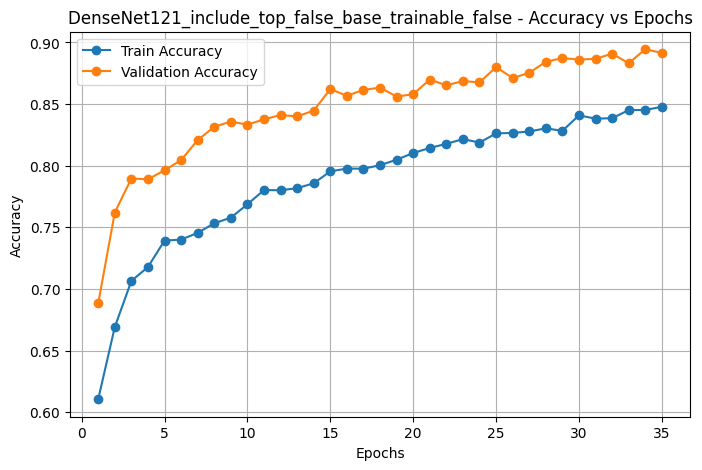

Saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/DenseNet121_include_top_false_base_trainable_false_accuracy_vs_epochs.png


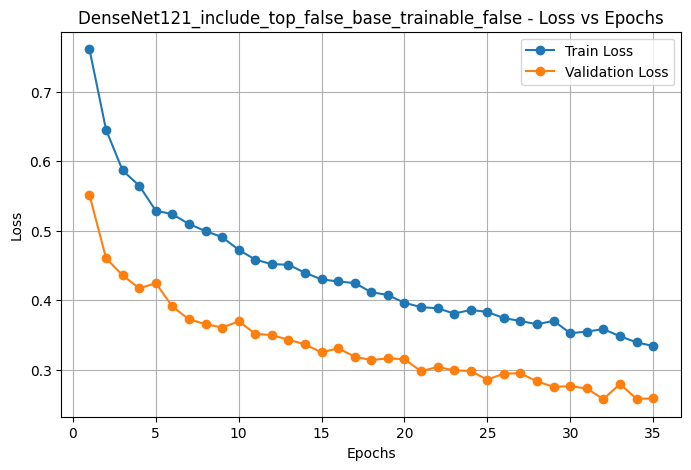

Saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/DenseNet121_include_top_false_base_trainable_false_loss_vs_epochs.png


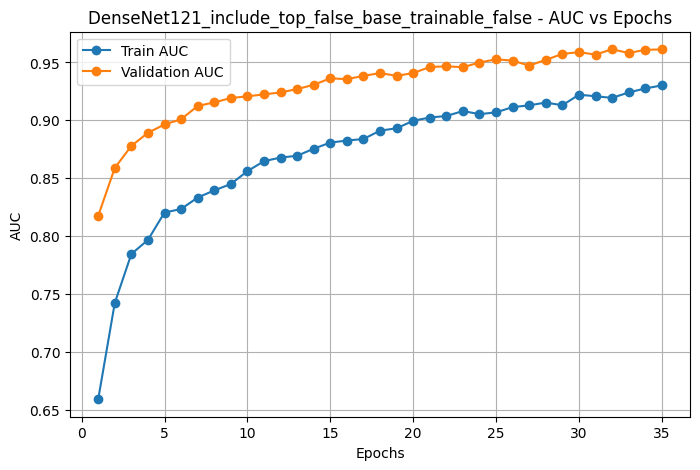

Saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/DenseNet121_include_top_false_base_trainable_false_auc_vs_epochs.png
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 319ms/step

DenseNet121_include_top_false_base_trainable_false
Accuracy: 0.8974820143884892
F1 Score: 0.8983957219251337
ROC AUC: 0.9675899568115292

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.90      0.89      0.90       834
   Parkinson       0.89      0.91      0.90       834

    accuracy                           0.90      1668
   macro avg       0.90      0.90      0.90      1668
weighted avg       0.90      0.90      0.90      1668


Confusion Matrix:
[[741  93]
 [ 78 756]]
Report saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/reports/DenseNet121_include_top_false_base_trainable_false_classification_report.txt
Confusion matrix CSV saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/confusi

<Figure size 600x600 with 0 Axes>

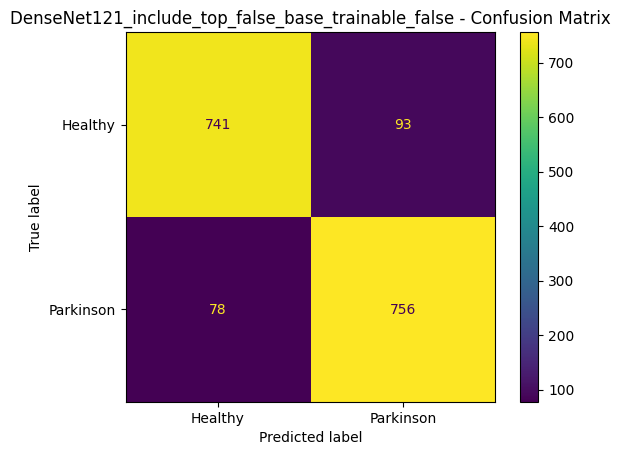

Confusion matrix image saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/confusion_matrices/DenseNet121_include_top_false_base_trainable_false_confusion_matrix.png


In [15]:
model_name_1 = "DenseNet121_include_top_false_base_trainable_false"

model_1 = build_densenet121_model(base_trainable=False)

model_1.summary()

callbacks_1 = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, f"{model_name_1}_best.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(
        filename=os.path.join(HISTORY_DIR, f"{model_name_1}_training_log.csv")
    )
]

start_time_1 = time.time()

history_1 = model_1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_1
)

end_time_1 = time.time()
runtime_1_seconds = end_time_1 - start_time_1
runtime_1 = format_runtime(runtime_1_seconds)

print("Model 1 Runtime:", runtime_1)

model_1_final_path = os.path.join(MODEL_DIR, f"{model_name_1}_final.keras")
model_1.save(model_1_final_path)
print("Final model saved:", model_1_final_path)

history_1_path = os.path.join(HISTORY_DIR, f"{model_name_1}_history.json")
with open(history_1_path, "w") as f:
    json.dump(history_1.history, f)

print("History saved:", history_1_path)

plot_training_history(history_1, model_name_1)

results_1 = evaluate_model(model_1, test_gen, model_name_1)
results_1["runtime"] = runtime_1

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,334,465 (27.98 MB)

 Trainable params: 7,250,049 (27.66 MB)

 Non-trainable params: 84,416 (329.75 KB)

Epoch 1/35
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.6606 - auc: 0.7303 - loss: 0.6550
Epoch 1: val_auc improved from None to 0.92114, saving model to /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/models/DenseNet121_include_top_false_base_trainable_true_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/models/DenseNet121_include_top_false_base_trainable_true_best.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 429s 1s/step - accuracy: 0.7172 - auc: 0.7993 - loss: 0.5682 - val_accuracy: 0.8177 - val_auc: 0.9211 - val_loss: 0.3721 - learning_rate: 1.0000e-04
Epoch 2/35
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8049 - auc: 0.9003 - loss: 0.4012
Epoch 2: val_auc improved from 0.92114 to 0.94695, saving model to /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/models/DenseNet121_include_top_false_base_trainable_true_best.keras

Epoch 2: finished saving model to /co

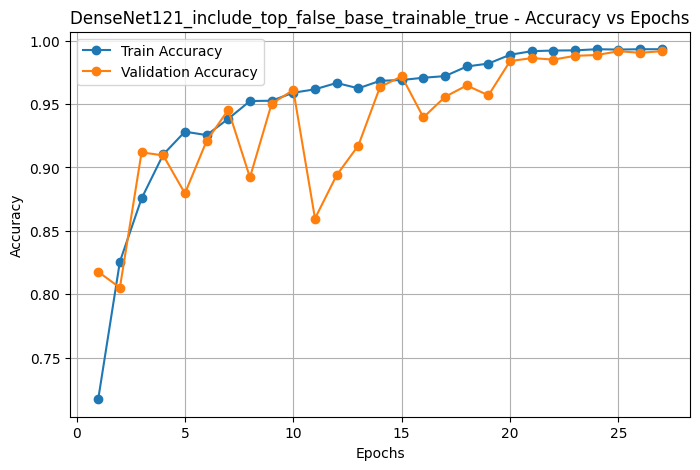

Saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/DenseNet121_include_top_false_base_trainable_true_accuracy_vs_epochs.png


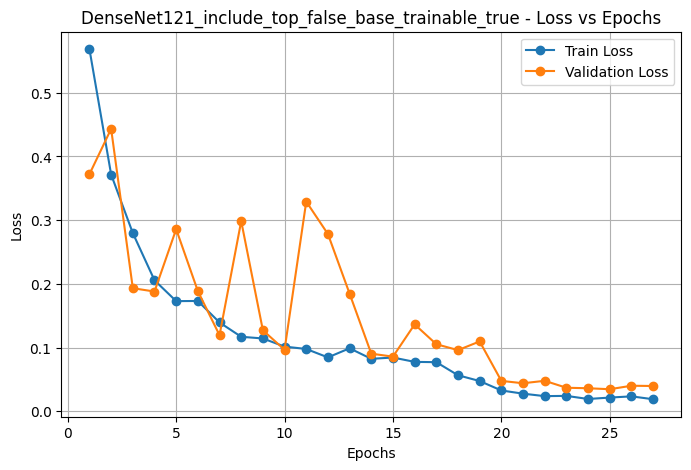

Saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/DenseNet121_include_top_false_base_trainable_true_loss_vs_epochs.png


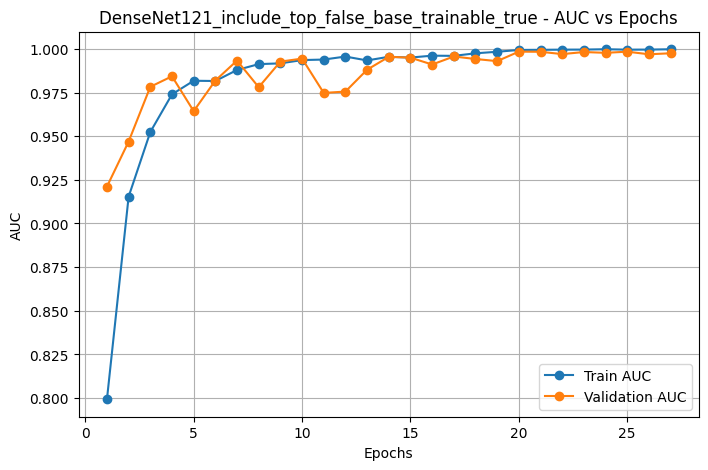

Saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/DenseNet121_include_top_false_base_trainable_true_auc_vs_epochs.png
53/53 ━━━━━━━━━━━━━━━━━━━━ 30s 323ms/step

DenseNet121_include_top_false_base_trainable_true
Accuracy: 0.9910071942446043
F1 Score: 0.9910873440285205
ROC AUC: 0.9995758788652533

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.98      0.99       834
   Parkinson       0.98      1.00      0.99       834

    accuracy                           0.99      1668
   macro avg       0.99      0.99      0.99      1668
weighted avg       0.99      0.99      0.99      1668


Confusion Matrix:
[[819  15]
 [  0 834]]
Report saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/reports/DenseNet121_include_top_false_base_trainable_true_classification_report.txt
Confusion matrix CSV saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/confusion_

<Figure size 600x600 with 0 Axes>

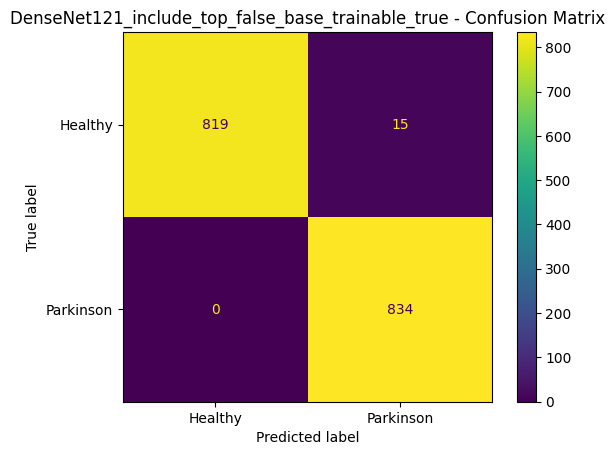

Confusion matrix image saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/confusion_matrices/DenseNet121_include_top_false_base_trainable_true_confusion_matrix.png


In [16]:
 model_name_2 = "DenseNet121_include_top_false_base_trainable_true"

model_2 = build_densenet121_model(base_trainable=True)

model_2.summary()

callbacks_2 = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, f"{model_name_2}_best.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(
        filename=os.path.join(HISTORY_DIR, f"{model_name_2}_training_log.csv")
    )
]

start_time_2 = time.time()

history_2 = model_2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_2
)

end_time_2 = time.time()
runtime_2_seconds = end_time_2 - start_time_2
runtime_2 = format_runtime(runtime_2_seconds)

print("Model 2 Runtime:", runtime_2)

model_2_final_path = os.path.join(MODEL_DIR, f"{model_name_2}_final.keras")
model_2.save(model_2_final_path)
print("Final model saved:", model_2_final_path)

history_2_path = os.path.join(HISTORY_DIR, f"{model_name_2}_history.json")
with open(history_2_path, "w") as f:
    json.dump(history_2.history, f)

print("History saved:", history_2_path)

plot_training_history(history_2, model_name_2)

results_2 = evaluate_model(model_2, test_gen, model_name_2)
results_2["runtime"] = runtime_2

In [17]:
import pickle
import os

# Use the predefined HISTORY_DIR for consistency
# os.makedirs(HISTORY_DIR, exist_ok=True) # This is already done at the start of the notebook

with open(
    os.path.join(HISTORY_DIR, "densenet_history.pkl"),
    "wb"
) as file:
    pickle.dump(history_2.history, file) # Assuming you want to save history_2 from the fine-tuned model

print("DenseNet history saved successfully:", os.path.join(HISTORY_DIR, "densenet_history.pkl"))

DenseNet history saved successfully: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/history_files/densenet_history.pkl


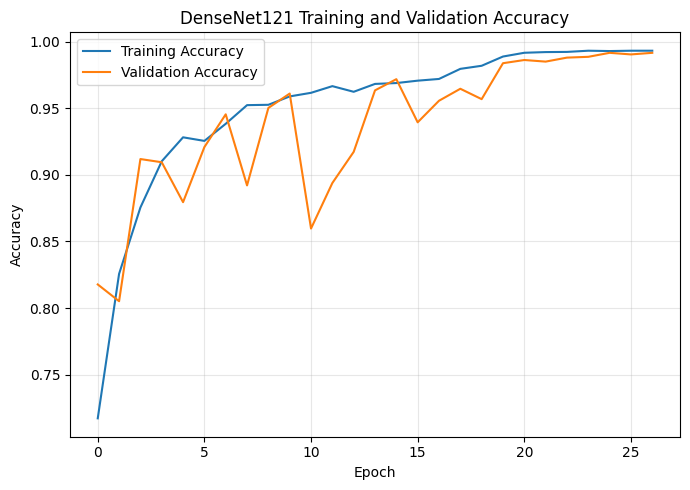

Saved accuracy plot to: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/densenet_accuracy.png


In [18]:
import matplotlib.pyplot as plt
import os
import json

# Use the predefined SAVE_DIR for consistency
os.makedirs(SAVE_DIR, exist_ok=True)

# Try to get history_2, if not defined, load it from the saved JSON file
if 'history_2' not in locals():
    history_2_json_path = os.path.join(HISTORY_DIR, "DenseNet121_include_top_false_base_trainable_true_history.json")
    if os.path.exists(history_2_json_path):
        print(f"Loading history from {history_2_json_path}")
        with open(history_2_json_path, 'r') as f:
            dense_history = json.load(f)
    else:
        raise FileNotFoundError(
            f"history_2 is not defined and its JSON file was not found at {history_2_json_path}. " +
            "Please ensure the model training cell (XSxKUyG8bAim) has been executed successfully."
        )
else:
    dense_history = history_2.history


plt.figure(figsize=(7, 5))

plt.plot(dense_history["accuracy"], label="Training Accuracy")
plt.plot(dense_history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet121 Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

accuracy_plot_path = os.path.join(SAVE_DIR, "densenet_accuracy.png")
plt.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(f"Saved accuracy plot to: {accuracy_plot_path}")

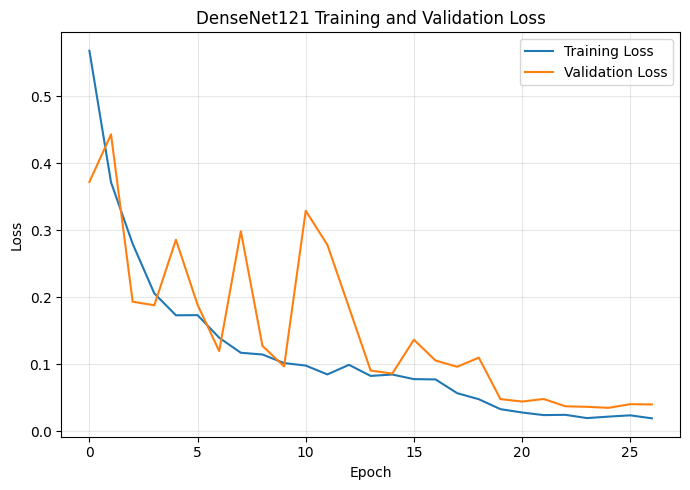

Saved loss plot to: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/densenet_loss.png


In [19]:
import matplotlib.pyplot as plt
import os
import json

# Use the predefined SAVE_DIR for consistency
os.makedirs(SAVE_DIR, exist_ok=True)

# Try to get history_2, if not defined, load it from the saved JSON file
if 'history_2' not in locals():
    history_2_json_path = os.path.join(HISTORY_DIR, "DenseNet121_include_top_false_base_trainable_true_history.json")
    if os.path.exists(history_2_json_path):
        print(f"Loading history from {history_2_json_path}")
        with open(history_2_json_path, 'r') as f:
            dense_history = json.load(f)
    else:
        raise FileNotFoundError(
            f"history_2 is not defined and its JSON file was not found at {history_2_json_path}. " +
            "Please ensure the model training cell (XSxKUyG8bAim) has been executed successfully."
        )
else:
    dense_history = history_2.history

plt.figure(figsize=(7, 5))

plt.plot(dense_history["loss"], label="Training Loss")
plt.plot(dense_history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_plot_path = os.path.join(SAVE_DIR, "densenet_loss.png")
plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(f"Saved loss plot to: {loss_plot_path}")

In [20]:
comparison_df = pd.DataFrame([
    {
        "Model": results_1["model_name"],
        "include_top": False,
        "base_trainable": False,
        "Accuracy": results_1["accuracy"],
        "F1 Score": results_1["f1_score"],
        "ROC AUC": results_1["roc_auc"],
        "Runtime": results_1["runtime"]
    },
    {
        "Model": results_2["model_name"],
        "include_top": False,
        "base_trainable": True,
        "Accuracy": results_2["accuracy"],
        "F1 Score": results_2["f1_score"],
        "ROC AUC": results_2["roc_auc"],
        "Runtime": results_2["runtime"]
    }
])

comparison_path = os.path.join(REPORT_DIR, "densenet121_model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print("Comparison saved:", comparison_path)
comparison_df

Comparison saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/reports/densenet121_model_comparison.csv


,Model,include_top,base_trainable,Accuracy,F1 Score,ROC AUC,Runtime
0,DenseNet121_include_top_false_base_trainable_f...,False,False,0.897482,0.898396,0.967590,1 hours 2 minutes 5 seconds
1,DenseNet121_include_top_false_base_trainable_true,False,True,0.991007,0.991087,0.999576,0 hours 52 minutes 11 seconds


### Grad-CAM Visualization

Grad-CAM (Gradient-weighted Class Activation Mapping) helps visualize the regions in an image that are important for the model's prediction. Let's visualize Grad-CAM for a sample image from the test set.

In [132]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

def display_gradcam(img_path, heatmap, model_prediction_label, true_label_value, output_filename_prefix="", alpha=0.6):
    # 1. Load original image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image at {img_path}")
        return
    img = cv2.resize(img, (224, 224))

    # 2. ADVANCED MEDICAL NORMALIZATION
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # Stage A: Percentile Clipping (Removes extreme outliers/noise)
    p1, p99 = np.percentile(gray, (1, 99))
    gray_clipped = np.clip(gray, p1, p99)

    # Stage B: Min-Max stretch to 0-255
    gray_norm = (gray_clipped - p1) / (p99 - p1 + 1e-8) * 255.0
    gray_norm = gray_norm.astype(np.uint8)

    # Stage C: High-Contrast CLAHE
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    enhanced_gray = clahe.apply(gray_norm)

    # Convert back to RGB for display
    img_rgb = cv2.cvtColor(enhanced_gray, cv2.COLOR_GRAY2RGB)

    # 3. HEATMAP NORMALIZATION (Ensure hotspots are visible)
    heatmap = np.maximum(heatmap, 0)
    h_min, h_max = np.min(heatmap), np.max(heatmap)
    if h_max > h_min:
        heatmap = (heatmap - h_min) / (h_max - h_min)

    # 4. Resize and Colorize Heatmap
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # 5. SUPERIMPOSE
    superimposed_img = cv2.addWeighted(img_rgb, 0.6, heatmap_colored, 0.4, 0)

    label_names = {0: "Healthy", 1: "Parkinson"}
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title(f'Enhanced Anatomy (1-99% Clip + CLAHE)\nTrue: {label_names.get(true_label_value)}')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title('Normalized Activation Focus')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title(f'Overlay\nPred: {label_names.get(model_prediction_label)}')
    plt.axis('off')

    if output_filename_prefix and 'GRAPH_DIR' in globals():
        save_path = os.path.join(GRAPH_DIR, f"gradcam_{output_filename_prefix}.png")
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved visualization to: {save_path}")

    plt.tight_layout()
    plt.show()

===========================
MODEL SUMMARY AND PARAMETERS
===========================

In [133]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# Define the directory for ROC data and ensure it exists
ROC_DATA_DIR = "/content/drive/MyDrive/ROC_DATA"
os.makedirs(ROC_DATA_DIR, exist_ok=True)

# --- Ensure model_for_gradcam is loaded --- (Robust Loading)
# These variables should ideally be in scope from earlier cells (e.g., fa7831f0)
# but are defined here for robustness in case of out-of-order execution or kernel reset.
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here"
MODEL_DIR = os.path.join(SAVE_DIR, "models")
model_name_2 = "DenseNet121_include_top_false_base_trainable_true"

potential_best_model_path = os.path.join(MODEL_DIR, f"{model_name_2}_best.keras")
final_model_path = os.path.join(MODEL_DIR, f"{model_name_2}_final.keras")

if 'model_for_gradcam' not in locals():
    print("model_for_gradcam not found in scope. Attempting to load model...")
    if os.path.exists(potential_best_model_path):
        model_for_gradcam = keras.models.load_model(potential_best_model_path)
        print(f"Model loaded successfully from: {potential_best_model_path}")
    elif os.path.exists(final_model_path):
        model_for_gradcam = keras.models.load_model(final_model_path)
        print(f"Model loaded successfully from: {final_model_path} (best model not found, loaded final model instead).")
    else:
        raise FileNotFoundError(
            f"Neither model file found at {potential_best_model_path} nor {final_model_path}.\n" +
            "Please ensure the model training cells (specifically XSxKUyG8bAim) " +
            "have been executed successfully and saved the models to Google Drive."
        )
else:
    print("Using existing model_for_gradcam from memory.")

# 1. Print the complete model.summary()
print("\n--- Model Summary ---")
model_for_gradcam.summary()

# 2. Save the complete model summary to a text file
summary_file_path = os.path.join(ROC_DATA_DIR, "densenet_model_summary.txt")
with open(summary_file_path, 'w') as f:
    model_for_gradcam.summary(print_fn=lambda x: f.write(x + '\n'))
print(f"Model summary saved to: {summary_file_path}")

# 3. Calculate and print parameter counts
print("\n--- Model Parameters ---")
total_params = model_for_gradcam.count_params()
trainable_params = sum(np.prod(v.shape) for v in model_for_gradcam.trainable_weights)
non_trainable_params = sum(np.prod(v.shape) for v in model_for_gradcam.non_trainable_weights)

print(f"Total Parameters: {total_params}")
print(f"Trainable Parameters: {trainable_params}")
print(f"Non-Trainable Parameters: {non_trainable_params}")

# 4. Save the parameter counts into a CSV file
param_df = pd.DataFrame({
    "Model Name": [model_name_2],
    "Total Parameters": [total_params],
    "Trainable Parameters": [trainable_params],
    "Non-Trainable Parameters": [non_trainable_params]
})
parameter_csv_path = os.path.join(ROC_DATA_DIR, "densenet_parameters.csv")
param_df.to_csv(parameter_csv_path, index=False)
print(f"Parameter counts saved to CSV: {parameter_csv_path}")

# 5. Save the parameter counts into a text file
parameter_txt_path = os.path.join(ROC_DATA_DIR, "densenet_parameters.txt")
with open(parameter_txt_path, 'w') as f:
    f.write(f"Model Name: {model_name_2}\n")
    f.write(f"Total Parameters: {total_params}\n")
    f.write(f"Trainable Parameters: {trainable_params}\n")
    f.write(f"Non-Trainable Parameters: {non_trainable_params}\n")
print(f"Parameter counts saved to TXT: {parameter_txt_path}")

Using existing model_for_gradcam from memory.

--- Model Summary ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,834,565 (83.29 MB)

 Trainable params: 7,250,049 (27.66 MB)

 Non-trainable params: 84,416 (329.75 KB)

 Optimizer params: 14,500,100 (55.31 MB)

Model summary saved to: /content/drive/MyDrive/ROC_DATA/densenet_model_summary.txt

--- Model Parameters ---
Total Parameters: 7334465
Trainable Parameters: 7250049
Non-Trainable Parameters: 84416
Parameter counts saved to CSV: /content/drive/MyDrive/ROC_DATA/densenet_parameters.csv
Parameter counts saved to TXT: /content/drive/MyDrive/ROC_DATA/densenet_parameters.txt


In [134]:
import os
import tensorflow as tf
from tensorflow import keras

# --- Ensure model_for_gradcam is loaded --- (Robust Loading)
# These variables should ideally be in scope from earlier cells (e.g., fa7831f0)
# but are defined here for robustness in case of out-of-order execution or kernel reset.
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here"
MODEL_DIR = os.path.join(SAVE_DIR, "models")
model_name_2 = "DenseNet121_include_top_false_base_trainable_true"
potential_best_model_path = os.path.join(MODEL_DIR, f"{model_name_2}_best.keras")
final_model_path = os.path.join(MODEL_DIR, f"{model_name_2}_final.keras")

ROC_DATA_DIR = "/content/drive/MyDrive/ROC_DATA"
os.makedirs(ROC_DATA_DIR, exist_ok=True)

if 'model_for_gradcam' not in locals():
    print("model_for_gradcam not found in scope. Attempting to load model...")
    if os.path.exists(potential_best_model_path):
        model_for_gradcam = keras.models.load_model(potential_best_model_path)
        print(f"Model loaded successfully for architecture diagram generation from: {potential_best_model_path}")
    elif os.path.exists(final_model_path):
        model_for_gradcam = keras.models.load_model(final_model_path)
        print(f"Model loaded successfully for architecture diagram generation from: {final_model_path} (best model not found, loaded final model instead).")
    else:
        raise FileNotFoundError(
            f"Neither model file found at {potential_best_model_path} nor {final_model_path}.\n" +
            "Please ensure the model training cells (specifically XSxKUyG8bAim) " +
            "have been executed successfully and saved the models to Google Drive."
        )
else:
    print("Using existing model_for_gradcam from memory.")

# 6. Generate the architecture diagram
print("\n--- Generating Model Architecture Diagram ---")
architecture_diagram_path = os.path.join(ROC_DATA_DIR, "densenet_architecture.png")

try:
    tf.keras.utils.plot_model(
        model_for_gradcam,
        to_file=architecture_diagram_path,
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        expand_nested=True,
        dpi=300
    )
    print(f"Model architecture diagram saved to: {architecture_diagram_path}")
except ImportError:
    print("Graphviz is not installed. Skipping model architecture diagram generation.")
    print("To enable this feature, please install Graphviz (e.g., `pip install graphviz pydotplus`) ")
    print("and ensure it's in your system's PATH, or run `!apt-get install graphviz -y` in Colab.")

Using existing model_for_gradcam from memory.

--- Generating Model Architecture Diagram ---
Model architecture diagram saved to: /content/drive/MyDrive/ROC_DATA/densenet_architecture.png


In [135]:
def make_gradcam_heatmap_fixed(img_array, model, last_conv_layer_name):
    # Extract the internal DenseNet121 base to access layers directly
    base_model = model.get_layer('densenet121')
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Create a sub-model that outputs both the last conv layer and the base model's final features
    grad_model = tf.keras.models.Model(
        inputs=[base_model.input],
        outputs=[last_conv_layer.output, base_model.output]
    )

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        conv_outputs, base_output = grad_model(inputs, training=False)

        # Manually run the head of the model (Dense layers) using the base output
        # We stop BEFORE the final Sigmoid to get 'logits' which have stronger gradients
        x = base_output
        found_base = False
        for layer in model.layers:
            if not found_base:
                if layer.name == 'densenet121':
                    found_base = True
                continue
            if layer == model.layers[-1]: # Stop before final activation (Sigmoid)
                break
            try:
                x = layer(x, training=False)
            except TypeError:
                x = layer(x)

        class_channel = x[:, 0]

    # Calculate gradients of the logit w.r.t the last conv layer feature map
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Compute the weighted sum of the feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU to keep only positive contributions (features that increase score)
    heatmap = tf.maximum(heatmap, 0)

    # --- Aggressive Sharpening (High Gamma Transform) ---
    # This suppresses the 'solid color' effect by pushing low-intensity areas to zero
    max_val = tf.reduce_max(heatmap)
    if max_val > 1e-10:
        heatmap = heatmap / max_val
        # Power of 3.0 highlights sharp focal points and removes background noise
        heatmap = tf.pow(heatmap, 3.0)
    else:
        heatmap = tf.zeros_like(heatmap)

    return heatmap.numpy()

Saved visualization to: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/gradcam_single_fixed_pred_0_true_0.png


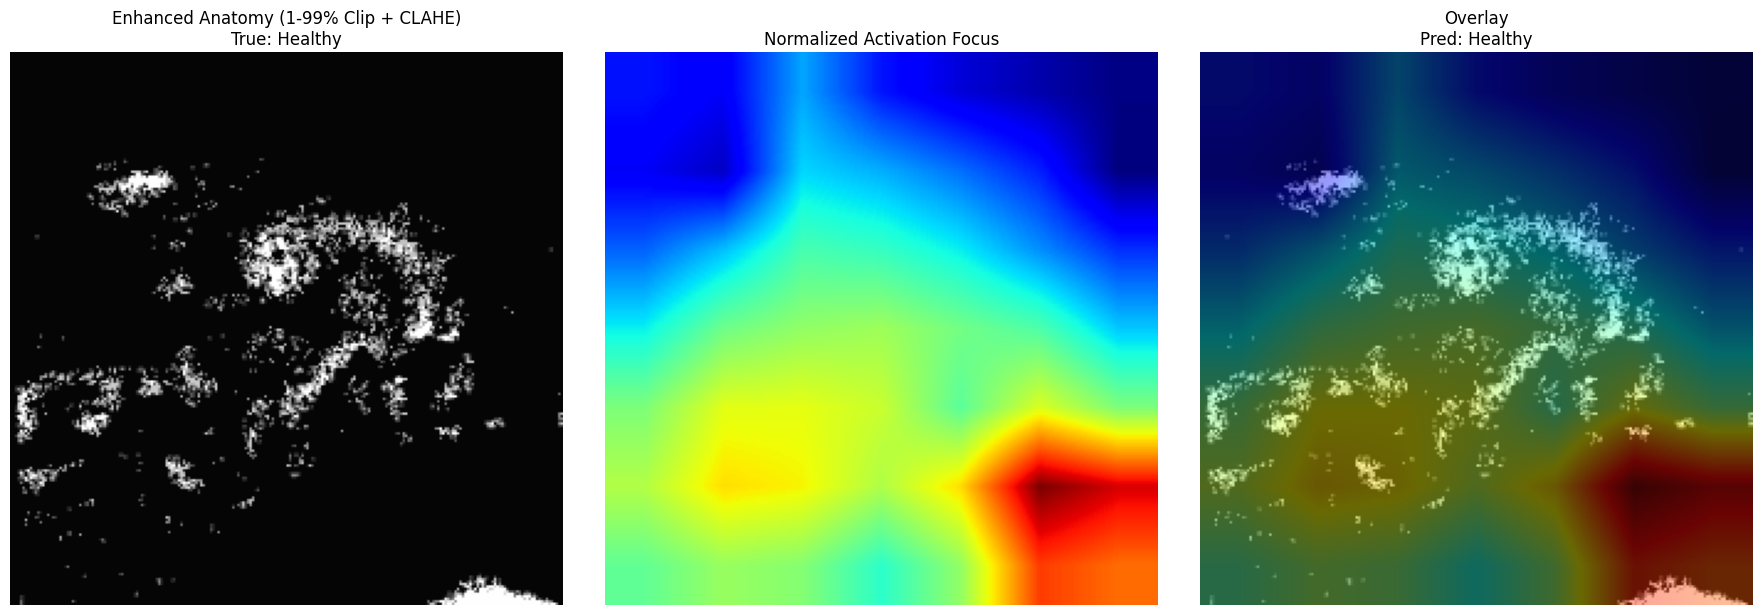

In [136]:
# --- Display Single-Image Grad-CAM ---
# Using the heatmap generated from the fixed function
display_gradcam(
    img_path=sample_image_path,
    heatmap=heatmap,
    model_prediction_label=predicted_label,
    true_label_value=int(sample_true_label),
    output_filename_prefix=f"single_fixed_pred_{predicted_label}_true_{sample_true_label}"
)

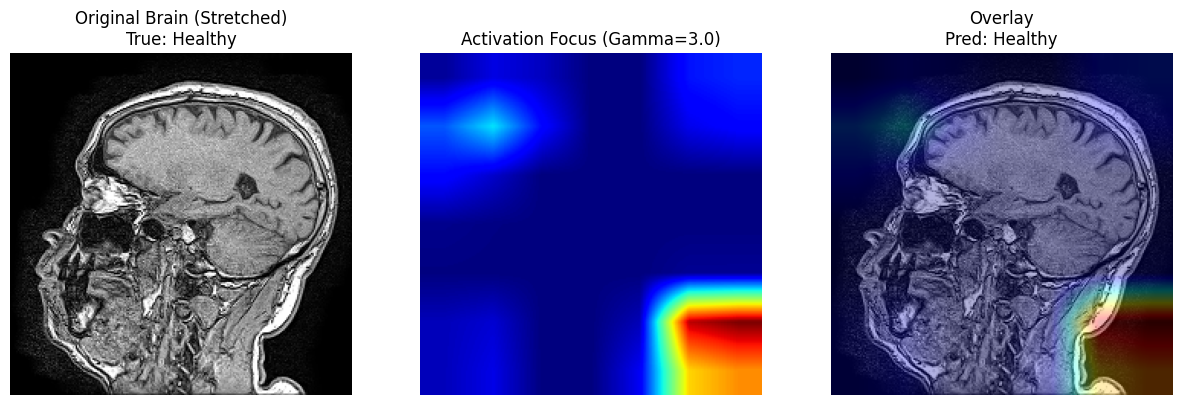

Image: /content/drive/MyDrive/Colab Notebooks/Parkinson_densetnet121_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_149807_MR_3D_T1-weighted_br_raw_20220828213916867_239_S1156481_I1617099.png
True Label: 0 | Predicted: 0 (Prob: 0.0001)


In [116]:
import numpy as np
import tensorflow as tf

# 1. Select a fresh sample from the test dataframe
sample_row = test_df.iloc[5] # Index 5 usually provides a clear anatomical slice
sample_path = sample_row['image_path']
sample_true_label = int(sample_row['label'])

# 2. Load and Preprocess specifically for the model
img = tf.keras.utils.load_img(sample_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.utils.img_to_array(img)
img_array_expanded = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_array_expanded)

# 3. Get Prediction
preds = model_for_gradcam.predict(img_preprocessed, verbose=0)
pred_prob = preds[0][0]
pred_label = int(round(pred_prob))

# 4. Generate the Fixed Heatmap (with Gamma 3.0 sharpening)
heatmap_result = make_gradcam_heatmap_fixed(
    img_preprocessed,
    model_for_gradcam,
    "conv5_block16_2_conv"
)

# 5. Display with Percentile Stretching to show anatomy
display_gradcam(
    img_path=sample_path,
    heatmap=heatmap_result,
    model_prediction_label=pred_label,
    true_label_value=sample_true_label,
    output_filename_prefix="single_image_fixed_check"
)

print(f"Image: {sample_path}")
print(f"True Label: {sample_true_label} | Predicted: {pred_label} (Prob: {pred_prob:.4f})")

Re-generating visualizations with Histogram Equalization...


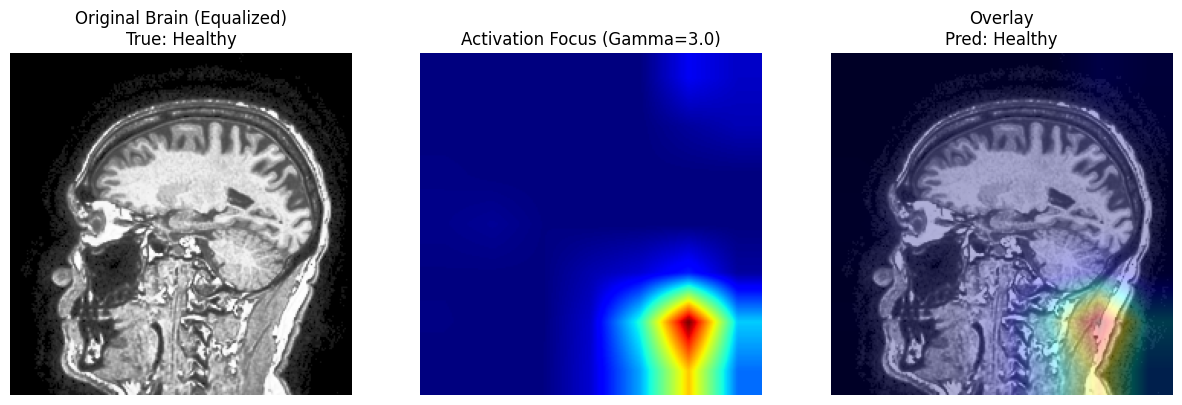

Processed image 1: Prob 0.0002 | Heatmap Max: 1.0000


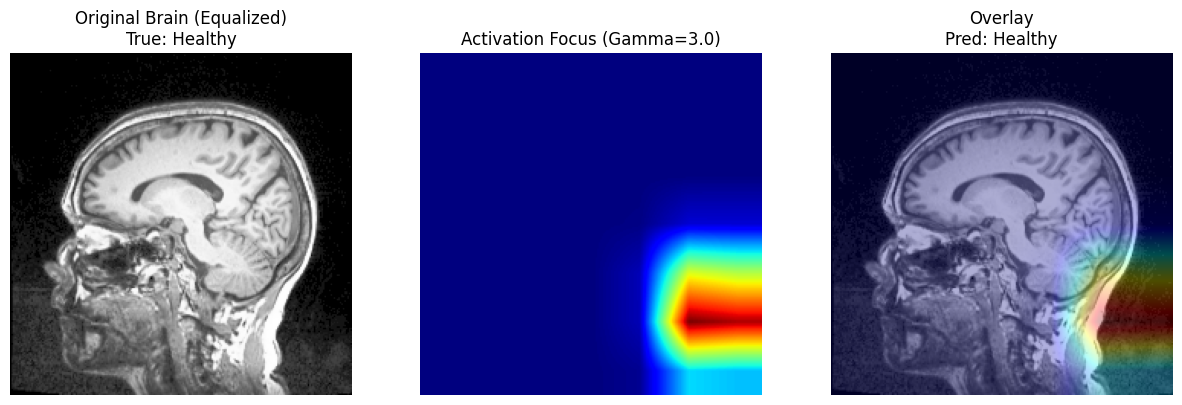

Processed image 4: Prob 0.0001 | Heatmap Max: 1.0000


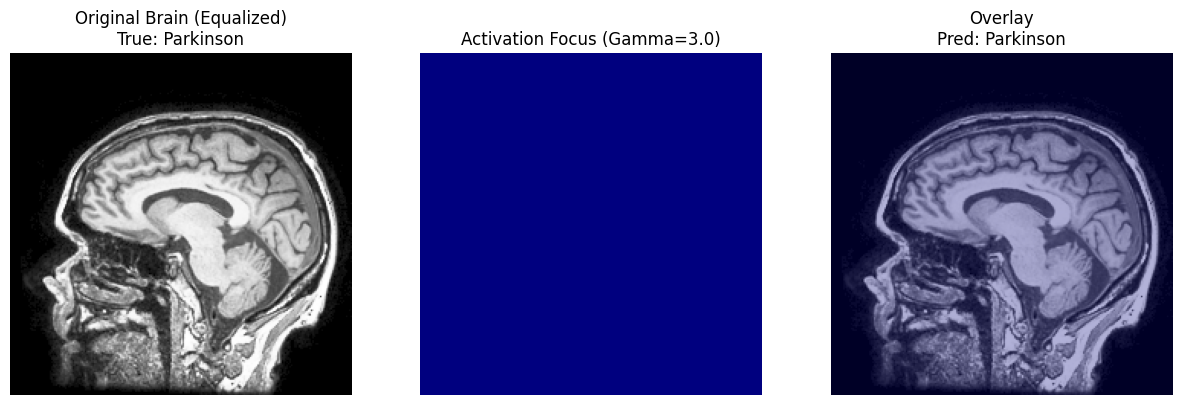

Processed image 0: Prob 0.9997 | Heatmap Max: 0.0000


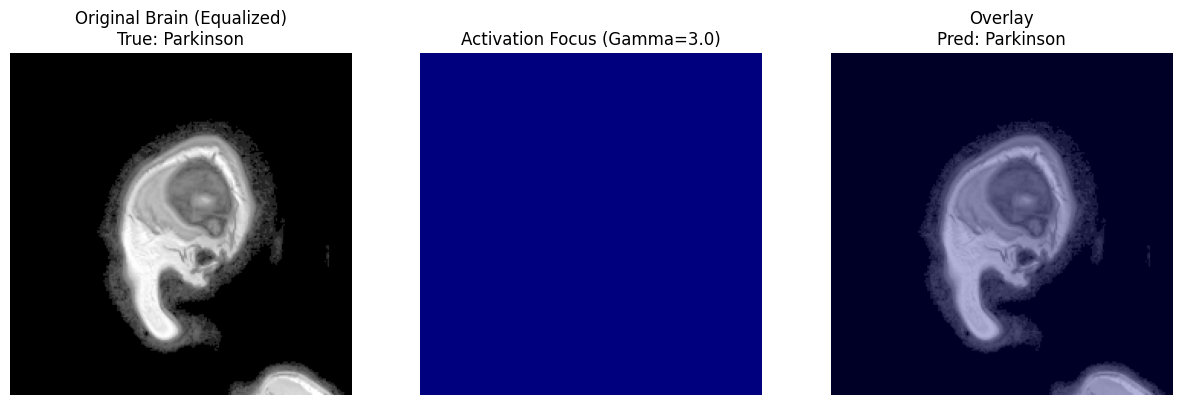

Processed image 2: Prob 0.9988 | Heatmap Max: 0.0000


In [104]:
# Re-run visualization with Histogram Equalization to fix the 'black image' issue
print("Re-generating visualizations with Histogram Equalization...")

# Ensure we are sampling from the current dataframe 'df'
healthy_samples = df[df['label'].astype(str) == '0'].head(2)
parkinson_samples = df[df['label'].astype(str) == '1'].head(2)
images_to_process = pd.concat([healthy_samples, parkinson_samples])

for idx, row in images_to_process.iterrows():
    img_path = row['image_path']
    true_label = int(row['label'])

    # Preprocess for model
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Predict
    predictions = model_for_gradcam.predict(img_array, verbose=0)
    pred_prob = predictions[0][0]
    pred_label = int(round(pred_prob))

    # Generate heatmap using the sharpened (Gamma 3.0) function
    heatmap_multi = make_gradcam_heatmap_fixed(img_array, model_for_gradcam, "conv5_block16_2_conv")

    # Display result (The updated fa7831f0 function now handles Histogram Equalization)
    display_gradcam(
        img_path=img_path,
        heatmap=heatmap_multi,
        model_prediction_label=pred_label,
        true_label_value=true_label,
        output_filename_prefix=f"equalized_anatomy_{true_label}_{idx}"
    )
    print(f"Processed image {idx}: Prob {pred_prob:.4f} | Heatmap Max: {np.max(heatmap_multi):.4f}")

### Anatomical Reference
Depending on the slice depth, the model is likely looking at:
1. **Midbrain / Substantia Nigra**: Located near the center-bottom of the brain in axial/coronal views.
2. **Striatum (Caudate/Putamen)**: Located in the central 'core' of the brain.
3. **Ventricals**: The butterfly-shaped fluid spaces in the center.

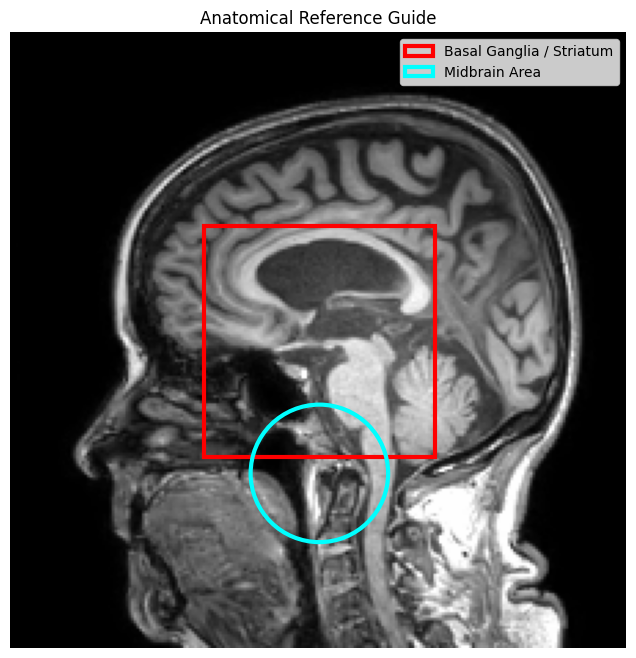

In [139]:
import matplotlib.patches as patches
import cv2

# 1. Load a sample image for the reference background
ref_path = test_df.iloc[0]['image_path']
img = cv2.imread(ref_path)
img = cv2.resize(img, (224, 224))

# 2. Apply the same normalization as the display function
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
p1, p99 = np.percentile(gray, (1, 99))
gray_clipped = np.clip(gray, p1, p99)
gray_norm = (gray_clipped - p1) / (p99 - p1 + 1e-8) * 255.0
img_rgb_ref = cv2.cvtColor(gray_norm.astype(np.uint8), cv2.COLOR_GRAY2RGB)

# 3. Plot with labels
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb_ref)
plt.title("Anatomical Reference Guide")

# Central region (Basal Ganglia / Striatum)
rect = patches.Rectangle((70, 70), 84, 84, linewidth=3, edgecolor='r', facecolor='none', label='Basal Ganglia / Striatum')
plt.gca().add_patch(rect)

# Bottom-Central region (Midbrain / Substantia Nigra area in axial view)
circle = patches.Circle((112, 160), 25, linewidth=3, edgecolor='cyan', facecolor='none', label='Midbrain Area')
plt.gca().add_patch(circle)

plt.legend(loc='upper right')
plt.axis('off')
plt.show()

### Middle Brain Structures Reference
In an axial (top-down) view, the **Basal Ganglia** are the heart of the brain. The following code highlights the 'Dead Center' and 'Midbrain' zones to confirm the model is focusing on the middle.

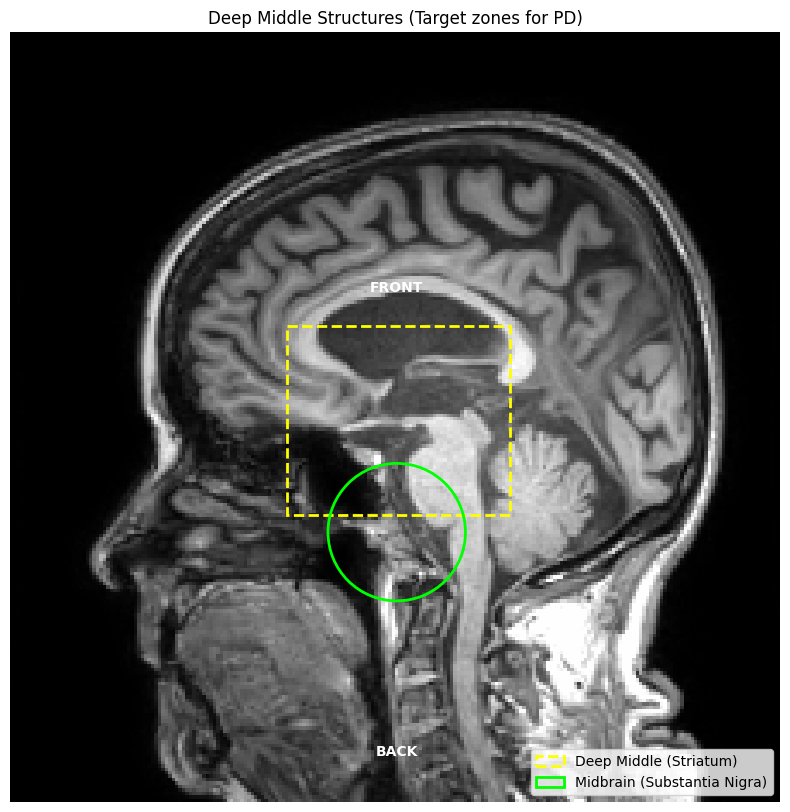

In [140]:
import matplotlib.patches as patches

# Create a focused view of the "Middle" structures
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb_ref)
plt.title("Deep Middle Structures (Target zones for PD)")

# Center-Middle: Striatum and Thalamus
rect_mid = patches.Rectangle((80, 85), 65, 55, linewidth=2, edgecolor='yellow', facecolor='none', linestyle='--', label='Deep Middle (Striatum)')
plt.gca().add_patch(rect_mid)

# Lower-Middle: Midbrain / Substantia Nigra
circle_sn = patches.Circle((112, 145), 20, linewidth=2, edgecolor='lime', facecolor='none', label='Midbrain (Substantia Nigra)')
plt.gca().add_patch(circle_sn)

plt.legend(loc='lower right')
plt.text(112, 75, "FRONT", color='white', ha='center', fontweight='bold')
plt.text(112, 210, "BACK", color='white', ha='center', fontweight='bold')
plt.axis('off')
plt.show()

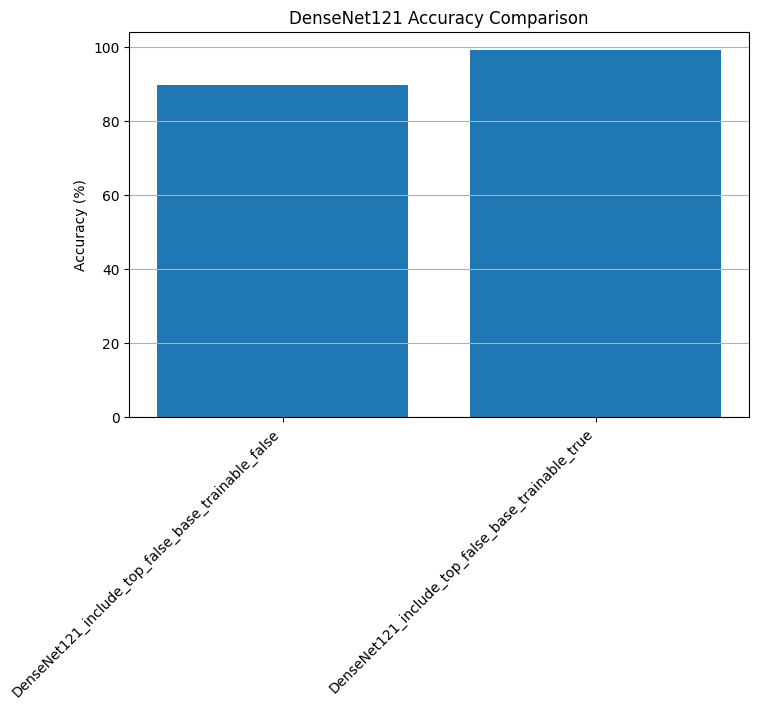

Saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/densenet121_accuracy_comparison.png


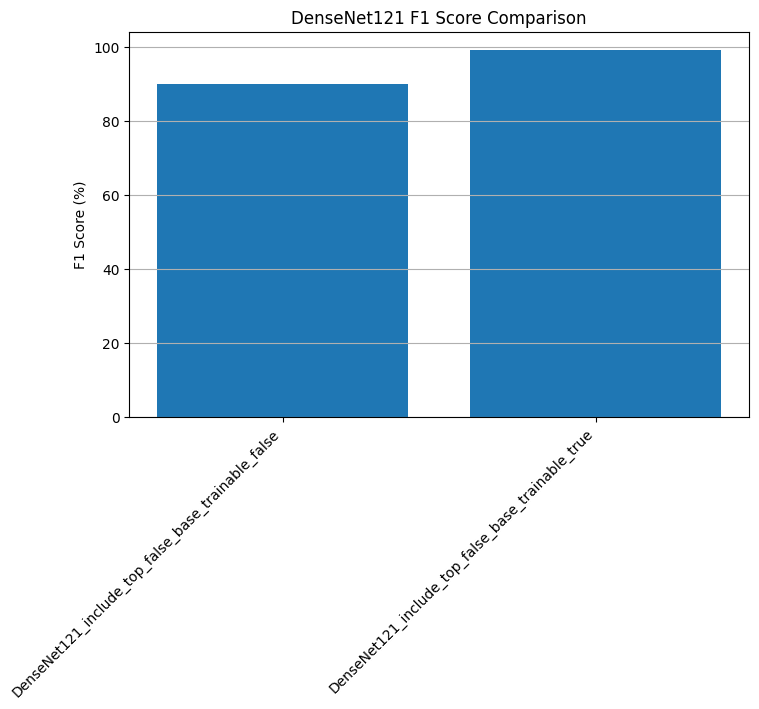

Saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/densenet121_f1_comparison.png


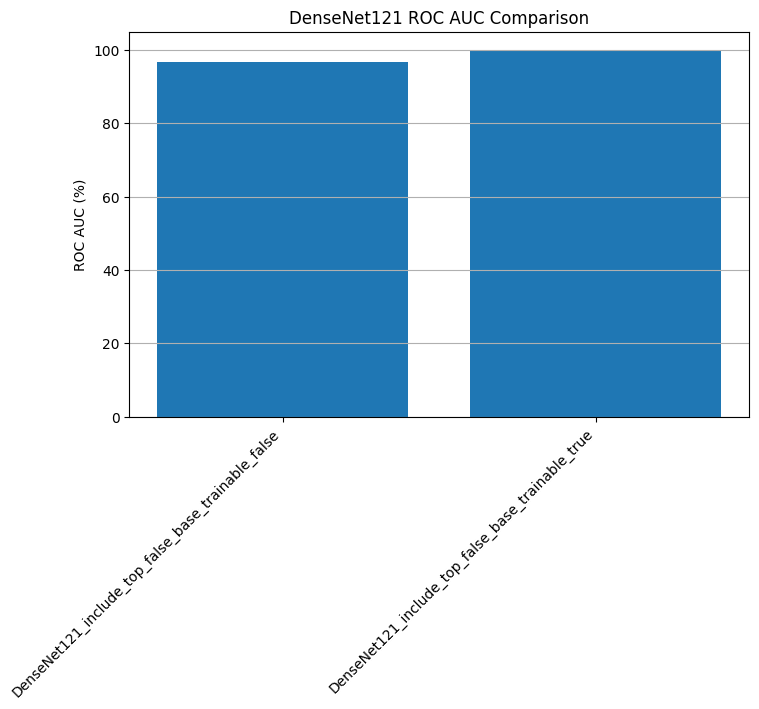

Saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/densenet121_auc_comparison.png


In [142]:
# Accuracy comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"] * 100)
plt.title("DenseNet121 Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
acc_compare_path = os.path.join(GRAPH_DIR, "densenet121_accuracy_comparison.png")
plt.savefig(acc_compare_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", acc_compare_path)

# F1 comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["F1 Score"] * 100)
plt.title("DenseNet121 F1 Score Comparison")
plt.ylabel("F1 Score (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
f1_compare_path = os.path.join(GRAPH_DIR, "densenet121_f1_comparison.png")
plt.savefig(f1_compare_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", f1_compare_path)

# ROC AUC comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["ROC AUC"] * 100)
plt.title("DenseNet121 ROC AUC Comparison")
plt.ylabel("ROC AUC (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
auc_compare_path = os.path.join(GRAPH_DIR, "densenet121_auc_comparison.png")
plt.savefig(auc_compare_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", auc_compare_path)


Using existing model_2 from memory.
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step


<Figure size 800x600 with 0 Axes>

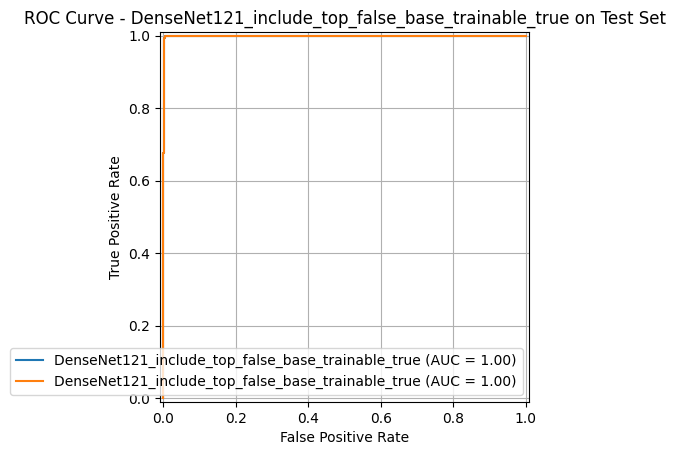

Saved: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs/DenseNet121_include_top_false_base_trainable_true_roc_curve.png


In [143]:
from sklearn.metrics import RocCurveDisplay
import os
import matplotlib.pyplot as plt
import tensorflow as tf

# Ensure test_gen is reset before prediction
test_gen.reset()

# Ensure MODEL_DIR and model_name_2 are available
# These should be defined in earlier cells (e.g., HMof8QN1a_6Q and XSxKUyG8bAim)
# If running this cell independently, ensure they are in scope or define them here.
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/models'
model_name_2 = "DenseNet121_include_top_false_base_trainable_true"
GRAPH_DIR = '/content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs'

# Load the best performing model (model_2 with base_trainable=True)
best_model_path = os.path.join(MODEL_DIR, f"{model_name_2}_best.keras")

# Check if model_2 is already defined and loaded, otherwise load it
if 'model_2' not in locals() or not isinstance(model_2, tf.keras.Model):
    if not os.path.exists(best_model_path):
        raise FileNotFoundError(
            f"Model file not found at {best_model_path}.\n" +
            "Please ensure the model training cells (specifically XSxKUyG8bAim) " +
            "have been executed successfully and saved the models to Google Drive."
        )
    print(f"Loading model from: {best_model_path}")
    model_2 = tf.keras.models.load_model(best_model_path)
else:
    print("Using existing model_2 from memory.")


y_prob_model_2 = model_2.predict(test_gen)
y_true_model_2 = test_gen.classes

# Plot ROC curve
plt.figure(figsize=(8, 6))
roc_display = RocCurveDisplay.from_predictions(
    y_true_model_2,
    y_prob_model_2,
    name=model_name_2
)
roc_display.plot(ax=plt.gca())
plt.title(f'ROC Curve - {model_name_2} on Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
roc_curve_path = os.path.join(GRAPH_DIR, f'{model_name_2}_roc_curve.png')
plt.savefig(roc_curve_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", roc_curve_path)

In [144]:
import numpy as np
import os

# Define the path to save the .npz file
save_roc_data_path = os.path.join(REPORT_DIR, "densenet_roc_data.npz")

# Save y_true and y_prob to a .npz file
np.savez(
    save_roc_data_path,
    y_true=y_true_model_2,
    y_prob=y_prob_model_2
)

print(f"Saved ROC data to: {save_roc_data_path}")

Saved ROC data to: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/reports/densenet_roc_data.npz


In [146]:
print("Models saved in:", MODEL_DIR)
print(os.listdir(MODEL_DIR))

print("\nGraphs saved in:", GRAPH_DIR)
print(os.listdir(GRAPH_DIR))

print("\nConfusion matrices saved in:", CM_DIR)
print(os.listdir(CM_DIR))

print("\nReports saved in:", REPORT_DIR)
print(os.listdir(REPORT_DIR))

print("\nHistory files saved in:", HISTORY_DIR)
print(os.listdir(HISTORY_DIR))

Models saved in: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/models
['DenseNet121_include_top_false_base_trainable_true_final.keras', 'DenseNet121_include_top_false_base_trainable_false_final.keras', 'DenseNet121_include_top_false_base_trainable_true_best.keras', 'DenseNet121_include_top_false_base_trainable_false_best.keras']

Graphs saved in: /content/drive/MyDrive/Colab Notebooks/Densenet_121_result_saved_here/graphs
['densenet121_accuracy_comparison.png', 'densenet121_auc_comparison.png', 'densenet121_f1_comparison.png', 'DenseNet121_include_top_false_base_trainable_true_accuracy_vs_epochs.png', 'DenseNet121_include_top_false_base_trainable_true_auc_vs_epochs.png', 'DenseNet121_include_top_false_base_trainable_true_loss_vs_epochs.png', 'DenseNet121_include_top_false_base_trainable_true_roc_curve.png', 'DenseNet121_include_top_false_base_trainable_false_loss_vs_epochs.png', 'DenseNet121_include_top_false_base_trainable_false_accuracy_vs_epochs.png', 'DenseN

In [ ]:
print('Re-running model 2 training to ensure completion.')